# Procesado DAS paso a paso: f–k filter, downsample y envolvente Hilbert

Este notebook construye un dataset DAS **sintético** (una ballena fin emitiendo pulsos junto a un cable submarino) y muestra qué hace exactamente cada etapa del preprocesado.

**Por qué sintético:** usar datos generados nos permite saber dónde están las señales y por tanto *ver* qué se conserva y qué se elimina en cada filtro.

**Estructura:**
1. Generamos datos: matriz `(canales × tiempo)` con 4 llamadas de fin whale + ruido + interferencia de 50 Hz.
2. Visualizamos el espectro y el plano f–k para entender en qué se basa cada filtro.
3. Aplicamos **bandpass** (referencia rápida).
4. Aplicamos **f–k filter** y vemos el antes/después en el plano f–k.
5. **Downsampleamos** y discutimos por qué no se pierde información si se hace bien.
6. Calculamos la **envolvente Hilbert** y vemos cómo cambia tanto una traza como la imagen 2D.


## 0. Imports y parámetros

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, hilbert, decimate
from scipy.fft import fft2, ifft2, fftshift, ifftshift, fftfreq, fft

# Físicos
c_water = 1500.0   # m/s, velocidad del sonido en agua
f0      = 20.0     # Hz, frecuencia central del pulso fin whale

# Muestreo
fs = 200.0         # Hz, frecuencia de muestreo temporal
dt = 1.0 / fs
dx = 4.0           # m, espaciado entre canales del cable
nx = 600           # número de canales -> cable de 2400 m
nt = 6000          # número de muestras -> 30 s de grabación

x = np.arange(nx) * dx     # eje distancia [m]
t = np.arange(nt) * dt     # eje tiempo    [s]

print(f"Cable: {x[-1]:.0f} m, {nx} canales, dx = {dx} m")
print(f"Grabación: {t[-1]:.1f} s, fs = {fs} Hz")


Cable: 2396 m, 600 canales, dx = 4.0 m
Grabación: 30.0 s, fs = 200.0 Hz


## 1. Generamos datos sintéticos

Colocamos una ballena fija en el punto `(x0, h)` — es decir, a `x0` metros a lo largo del cable y a `h` metros de distancia perpendicular. Emite varios pulsos de ~1 s a lo largo de los 30 s de grabación.

**Por qué aparece el chevron (forma de "V" o "U"):** la ballena emite un pulso instantáneo en el tiempo `t_emit`. Ese pulso viaja en todas direcciones a velocidad `c_water` y llega a cada canal del cable con un retraso proporcional a la distancia. El canal más cercano a la ballena (`x = x0`) recibe el pulso primero; los canales lejanos lo reciben más tarde. La ecuación es:

$$ t_{arr}(x) = t_{emit} + \frac{\sqrt{(x - x_0)^2 + h^2}}{c_{water}} $$


Para hacerlo realista añadimos:
- **Ruido blanco gaussiano**, simula el ruido térmico/instrumental del interrogador.
- **Una sinusoide a 50 Hz idéntica en todos los canales**, simula una interferencia de flujo/equipos. En el plano f–k esto aparece como una línea horizontal en `f = 50 Hz`, `k = 0` — útil para ver luego cómo el f–k filter podría quitarla.


In [ ]:
# Posición de la ballena
x0 = 1200.0        # punto del cable más cercano a la ballena [m]
h  = 300.0         # distancia perpendicular cable-ballena [m]

# Tiempos de emisión de cada llamada
call_times = [4.0, 12.0, 20.0, 26.0]   # s
call_duration = 1.0                        # s

data = np.zeros((nx, nt), dtype=np.float32)

for t_emit in call_times:
    for ix in range(nx):
        dist  = np.sqrt((x[ix] - x0)**2 + h**2)
        t_arr = t_emit + dist / c_water
        amp = 1.0 / (1.0 + dist / 400.0)      # decae con la distancia

        # hacemos una mascara para añadir el pulso solo durante la duración de la llamada
        mask = (t >= t_arr) & (t < t_arr + call_duration)
        if not mask.any():
            continue
        # lt = tiempo relativo a la llegada de la llamada
        lt    = t[mask] - t_arr
        env   = np.exp(-((lt - 0.5)**2) / (2 * 0.18**2))  # ventana gaussiana
        phase = 2*np.pi*(18*lt + (4/(2*call_duration))*lt**2)  # chirp 18->22 Hz
        data[ix, mask] += amp * env * np.sin(phase)

# Añadimos ruido y la interferencia de 50 Hz
rng = np.random.default_rng(42)
data += 0.25 * rng.standard_normal(data.shape).astype(np.float32)
data += (0.4 * np.sin(2*np.pi*50*t)).astype(np.float32)[None, :]

print("data shape (canales, muestras):", data.shape)

data shape (canales, muestras): (600, 6000)


### Visualizamos el dato crudo

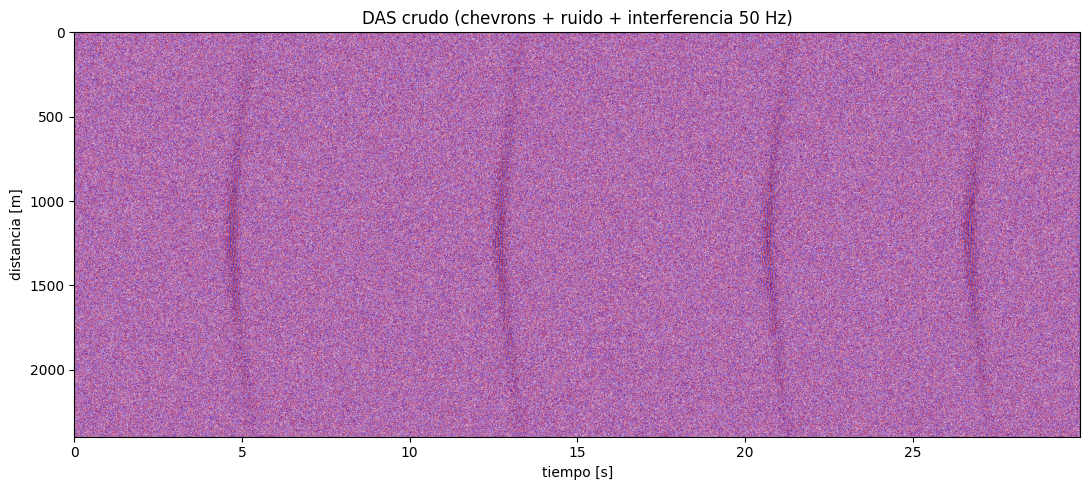

In [ ]:
def show(d, title, ax, t_axis=t, vmin=None, vmax=None, cmap='seismic'):
    if vmin is None:
        v = np.percentile(np.abs(d), 99)
        vmin, vmax = -v, v
    extent = [t_axis[0], t_axis[-1], x[-1], x[0]]
    im = ax.imshow(d, aspect='auto', cmap=cmap, extent=extent,
                   vmin=vmin, vmax=vmax)
    ax.set_xlabel('tiempo [s]'); ax.set_ylabel('distancia [m]')
    ax.set_title(title)
    return im

fig, ax = plt.subplots(figsize=(11, 5))
show(data, 'DAS crudo (chevrons + ruido + interferencia 50 Hz)', ax)
plt.tight_layout(); plt.show()


Si miras con atención puedes intuir los chevrons, pero el ruido los enmascara mucho. También notarás un patrón fino de rayas verticales/horizontales: ése es el aliasing visual de la sinusoide a 50 Hz superpuesta.

## 2. Espectro temporal: ¿en qué banda está la señal?

Antes de filtrar conviene mirar el contenido frecuencial. Promediamos la magnitud del espectro de todas las trazas (canales) para ver qué frecuencias dominan.

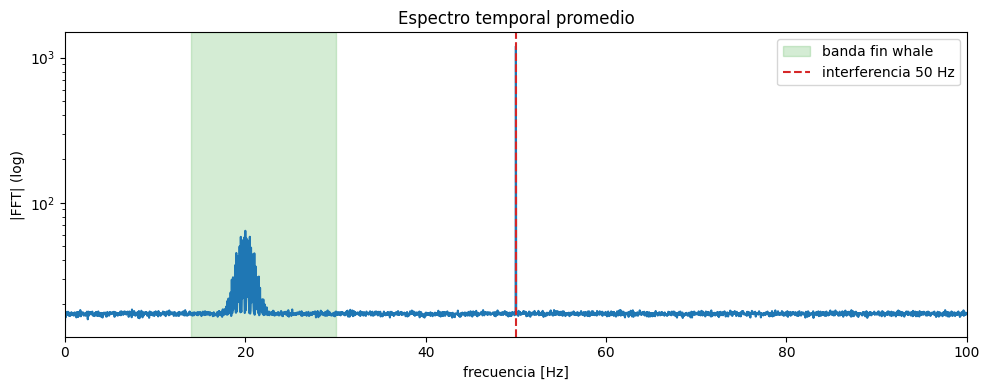

In [4]:
# Espectro promedio de todas las trazas
spec = np.abs(fft(data, axis=1))
spec_avg = spec.mean(axis=0)
freqs = fftfreq(nt, dt)
mask_pos = freqs >= 0

fig, ax = plt.subplots(figsize=(10, 4))
ax.semilogy(freqs[mask_pos], spec_avg[mask_pos])
ax.axvspan(14, 30, color='tab:green', alpha=0.2, label='banda fin whale')
ax.axvline(50, color='tab:red', ls='--', label='interferencia 50 Hz')
ax.set_xlabel('frecuencia [Hz]'); ax.set_ylabel('|FFT| (log)')
ax.set_xlim(0, 100); ax.legend()
ax.set_title('Espectro temporal promedio')
plt.tight_layout(); plt.show()


Vemos un pico grande en 50 Hz (la interferencia) y una joroba más ancha en 18–22 Hz (los chirps). Por eso un **bandpass 14–30 Hz** es el primer paso: tira fuera lo que está fuera de banda con muy poco coste.

## 3. Bandpass 14–30 Hz

Filtro Butterworth de orden 4 aplicado a lo largo del eje temporal (`axis=1`) con `filtfilt` para no introducir desfase.

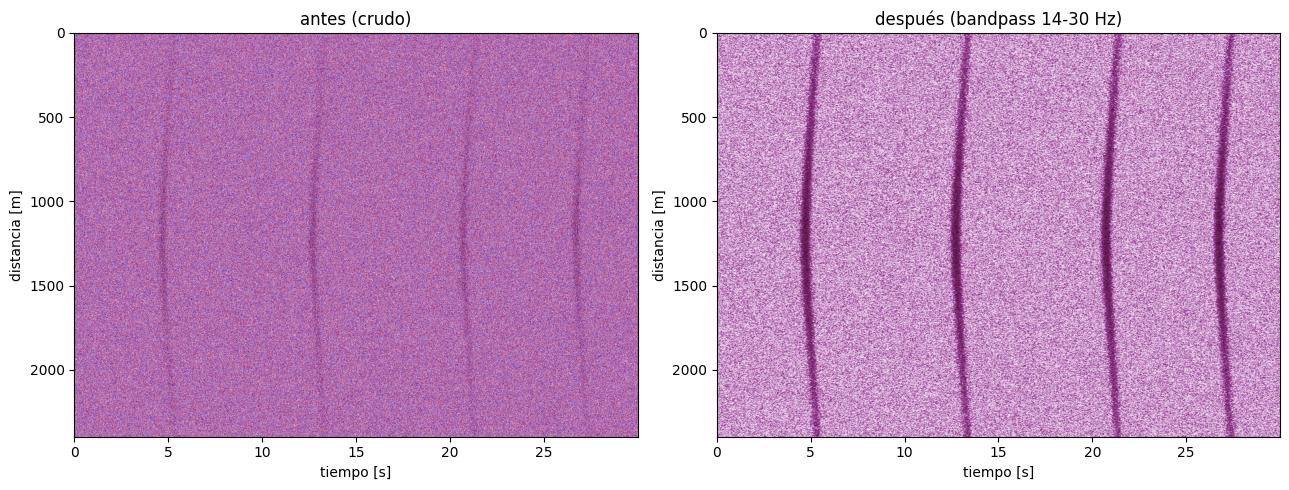

In [5]:
def bandpass(d, fs, lo, hi, order=4):
    b, a = butter(order, [lo, hi], btype='band', fs=fs)
    return filtfilt(b, a, d, axis=1)

bp = bandpass(data, fs, 14, 30)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
show(data, 'antes (crudo)', axes[0])
show(bp,   'después (bandpass 14-30 Hz)', axes[1])
plt.tight_layout(); plt.show()


El bandpass ya quita el 50 Hz y mucho ruido fuera de banda. Pero el ruido **dentro** de la banda (14–30 Hz) sigue ahí. Para eso necesitamos el f–k filter, que aprovecha información espacial.

## 4. f–k filter: el truco geométrico

### La intuición
Una señal acústica del agua que llega al cable lo hace con una **velocidad aparente** a lo largo del cable, `c_app = f / k`, donde `f` es la frecuencia temporal y `k` el número de onda espacial.

- Para una señal que llega perpendicular al cable, `c_app = ∞` (llega a todos los canales a la vez → línea horizontal en el espacio-tiempo, `k ≈ 0`).
- Para una señal rasante, `c_app = c_water` (llega siguiendo el cable a la velocidad del sonido en agua → línea inclinada).
- Para cualquier ángulo intermedio, `c_app ≥ c_water`.

**Por tanto, cualquier energía con `c_app < c_water` no puede venir del agua** — es ruido sísmico, ruido del propio cable, etc. En el plano f–k, eso son las regiones fuera del "cono" `|k| ≤ |f| / c_water`.

### El procedimiento
1. Calcular la FFT 2D de la imagen → plano f–k.
2. Construir una **máscara** que valga 1 dentro del cono físico y 0 fuera.
3. Multiplicar y hacer la FFT 2D inversa.

Vamos a verlo.

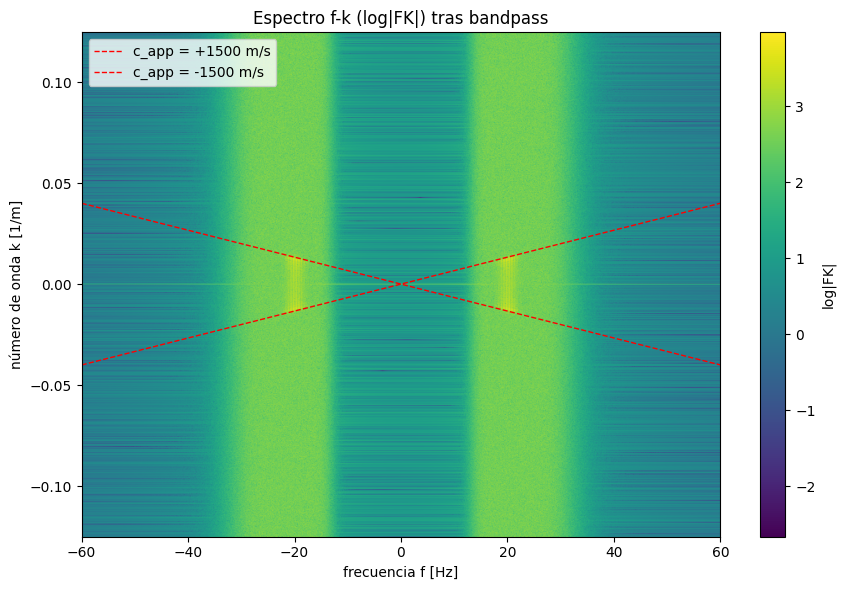

In [6]:
# FFT 2D y ejes f, k centrados (fftshift)
FK     = fftshift(fft2(bp))
f_axis = fftshift(fftfreq(nt, dt))   # Hz
k_axis = fftshift(fftfreq(nx, dx))   # 1/m

# Magnitud en escala log para visualizar
FK_mag = np.log10(np.abs(FK) + 1e-6)

fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(FK_mag, aspect='auto', cmap='viridis', origin='lower',
               extent=[f_axis[0], f_axis[-1], k_axis[0], k_axis[-1]])
ax.set_xlabel('frecuencia f [Hz]')
ax.set_ylabel('número de onda k [1/m]')
ax.set_title('Espectro f-k (log|FK|) tras bandpass')
ax.set_xlim(-60, 60)

# Superponemos las líneas del cono c_app = +/- c_water
f_line = np.linspace(-60, 60, 200)
ax.plot(f_line, f_line / c_water, 'r--', lw=1, label=f'c_app = +{c_water:.0f} m/s')
ax.plot(f_line, -f_line / c_water, 'r--', lw=1, label=f'c_app = -{c_water:.0f} m/s')
ax.legend(loc='upper left')
plt.colorbar(im, ax=ax, label='log|FK|')
plt.tight_layout(); plt.show()


Mira con atención: la **energía de la señal** (las llamadas reales) está concentrada en una franja que forma una **"X" tumbada** dentro del cono rojo, alrededor de 18–22 Hz. Eso es porque las llamadas llegan con `c_app ≥ c_water`.

Las regiones **fuera del cono rojo** contienen ruido que no respeta la física del sonido en agua — y eso es lo que vamos a tirar.

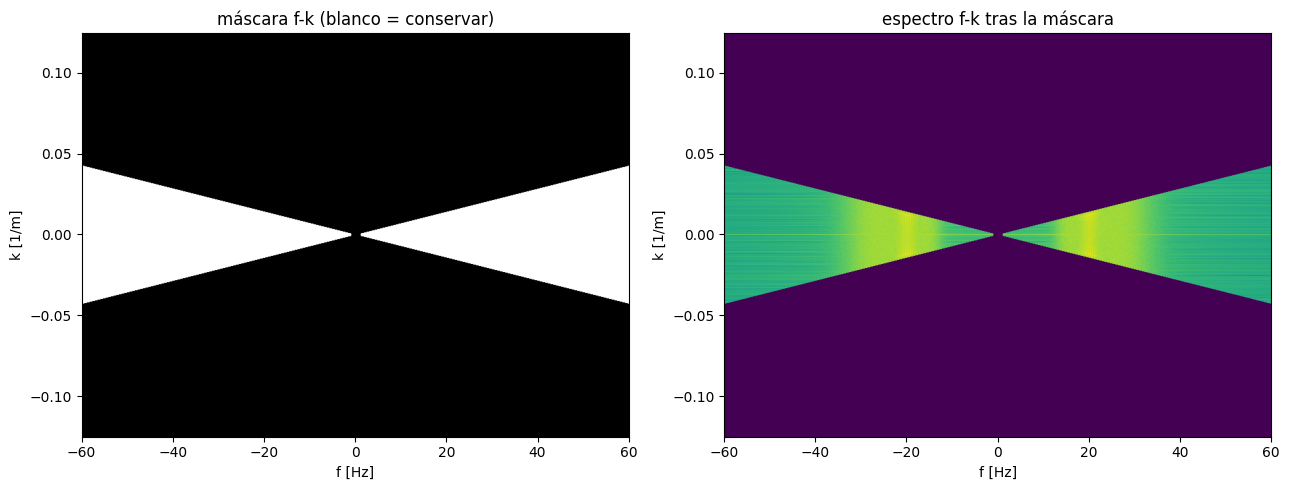

In [7]:
# Construimos la máscara: conservamos |c_app| >= c_min, descartamos lo demás
c_min = 1400.0       # un pelín más restrictivo que c_water para limpiar bordes
F, K = np.meshgrid(f_axis, k_axis)     # forma (nx, nt)

with np.errstate(divide='ignore', invalid='ignore'):
    keep = np.abs(K) <= np.abs(F) / c_min
keep &= np.abs(F) > 1.0     # eliminamos también la componente DC y ultra-baja frec.

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].imshow(keep.astype(float), aspect='auto', cmap='gray', origin='lower',
               extent=[f_axis[0], f_axis[-1], k_axis[0], k_axis[-1]])
axes[0].set_xlim(-60, 60); axes[0].set_title('máscara f-k (blanco = conservar)')
axes[0].set_xlabel('f [Hz]'); axes[0].set_ylabel('k [1/m]')

# espectro después de aplicar la máscara
FK_filt = FK * keep
axes[1].imshow(np.log10(np.abs(FK_filt) + 1e-6), aspect='auto', cmap='viridis',
               origin='lower',
               extent=[f_axis[0], f_axis[-1], k_axis[0], k_axis[-1]])
axes[1].set_xlim(-60, 60); axes[1].set_title('espectro f-k tras la máscara')
axes[1].set_xlabel('f [Hz]'); axes[1].set_ylabel('k [1/m]')
plt.tight_layout(); plt.show()


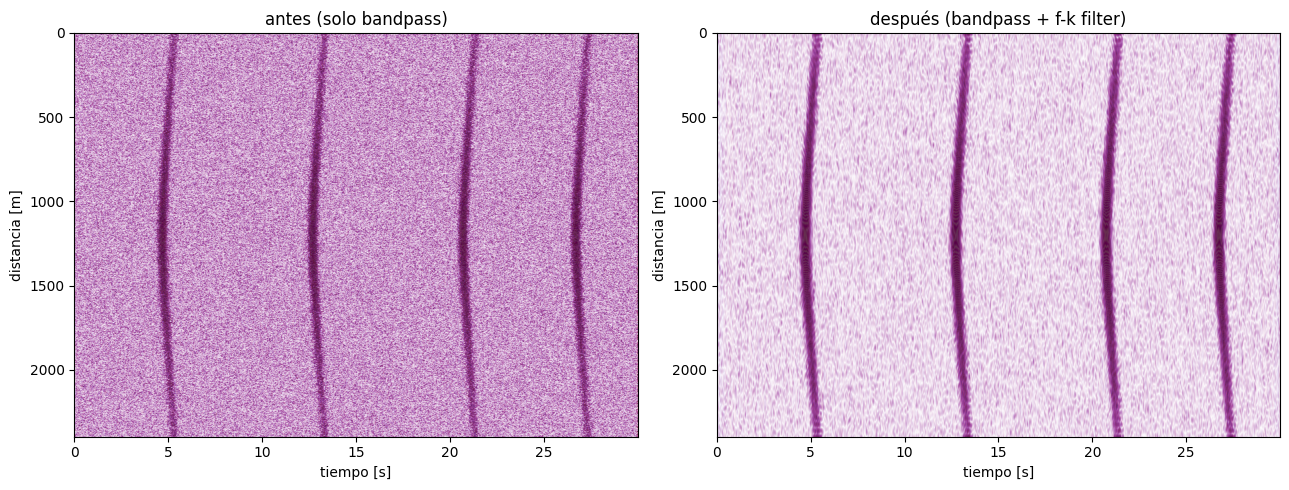

In [8]:
# Volvemos al dominio espacio-tiempo con FFT 2D inversa
fk_filtered = np.real(ifft2(ifftshift(FK_filt))).astype(np.float32)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
show(bp,          'antes (solo bandpass)', axes[0])
show(fk_filtered, 'después (bandpass + f-k filter)', axes[1])
plt.tight_layout(); plt.show()


Los chevrons ahora se ven mucho mejor: el f–k filter ha quitado el ruido que no respetaba la velocidad de propagación física.

## 5. Downsample temporal

### Por qué downsamplear
Después del bandpass nuestra señal está en 14–30 Hz. Por el **teorema de Nyquist**, con `fs = 200 Hz` estamos sobre-muestreando enormemente: bastaría con `fs ≥ 2·30 = 60 Hz` para representar la señal sin pérdida.

Bajar `fs` de 200 a 50 Hz nos divide el tamaño de la matriz por 4 — menos memoria, FFTs más rápidas, imágenes RGB más manejables — sin perder información acústica útil.

### Cómo hacerlo bien
**No** se hace tomando "una de cada N muestras". Eso introduce *aliasing* (frecuencias altas se pliegan sobre las bajas). El procedimiento correcto es:

1. **Filtro antialiasing** (lowpass) con corte por debajo de la nueva Nyquist.
2. *Después* coger una de cada N muestras.

`scipy.signal.decimate` hace las dos cosas en un solo paso. Con `zero_phase=True` aplica el filtro hacia adelante y hacia atrás para no introducir desfase (importante para preservar los tiempos de llegada del chevron).

Antes:    shape=(600, 6000), fs=200.0 Hz, Nyquist=100.0 Hz
Después:  shape=(600, 1500), fs=50.0 Hz, Nyquist=25.0 Hz


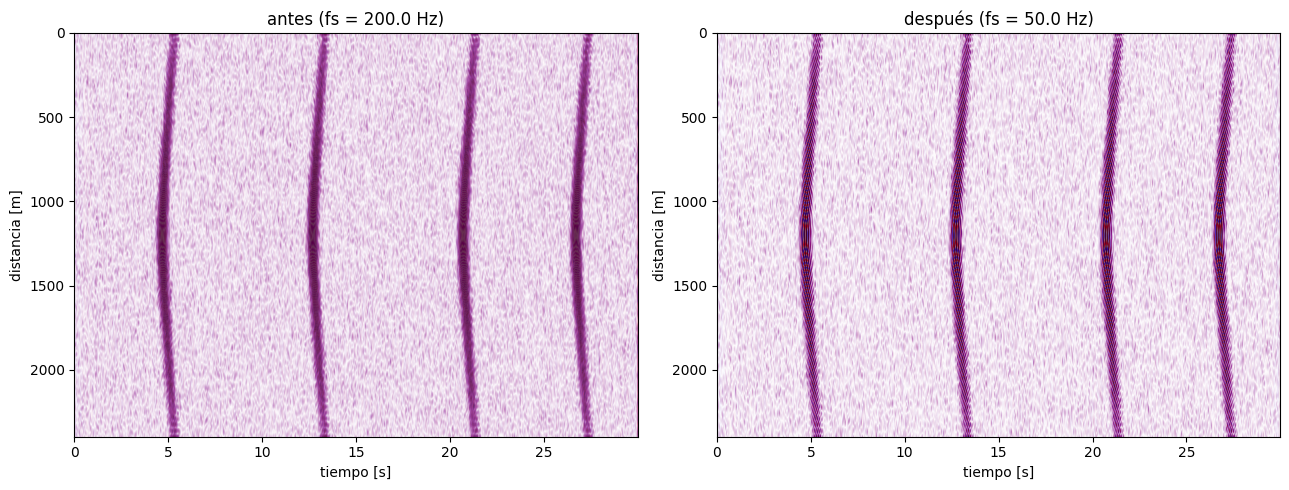

In [9]:
ds_factor = 4
ds   = decimate(fk_filtered, ds_factor, axis=1, ftype='fir', zero_phase=True)
fs_ds = fs / ds_factor
t_ds  = np.arange(ds.shape[1]) / fs_ds

print(f"Antes:    shape={fk_filtered.shape}, fs={fs} Hz, Nyquist={fs/2} Hz")
print(f"Después:  shape={ds.shape}, fs={fs_ds} Hz, Nyquist={fs_ds/2} Hz")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
show(fk_filtered, f'antes (fs = {fs} Hz)', axes[0])
show(ds,          f'después (fs = {fs_ds} Hz)', axes[1], t_axis=t_ds)
plt.tight_layout(); plt.show()


Visualmente son indistinguibles — la información del chevron está intacta. Pero la matriz pesa 1/4.

## 6. Envolvente Hilbert

### El problema
Un pulso de fin whale es una **oscilación rápida** modulada por una envolvente lenta. Lo que importa para detectarlo (y para entrenar YOLO) es **dónde y cuándo hay energía**, no el detalle de los ciclos.

### La solución: señal analítica
La transformada de Hilbert toma una señal real `x(t)` y construye una **señal analítica compleja** `x_a(t) = x(t) + i·H{x}(t)`, donde `H{x}` es la propia x con todas sus componentes desfasadas 90°. La magnitud `|x_a(t)|` es la **envolvente instantánea**: una curva suave que toca los picos de la señal.

Vamos a verlo primero en una sola traza (un canal cerca del foco) y luego en 2D.

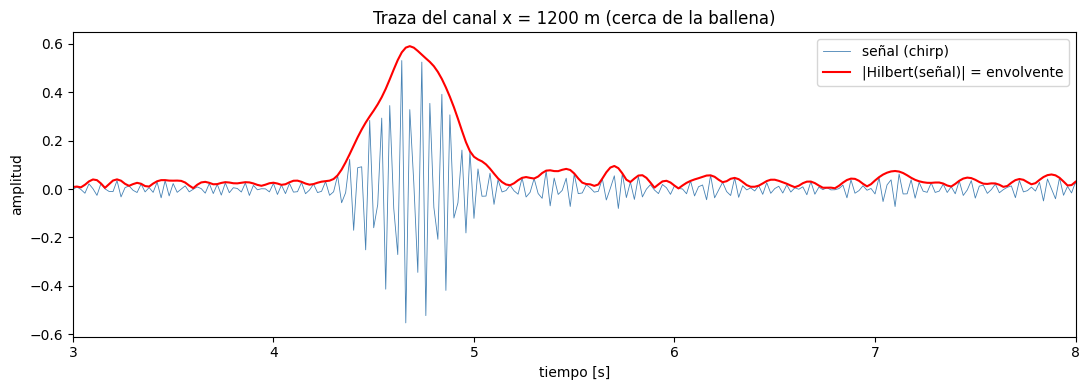

In [10]:
# Buscamos el canal más cercano a x0
ix_close = int(round(x0 / dx))
trace    = ds[ix_close]
env_1d   = np.abs(hilbert(trace))

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(t_ds, trace,  color='steelblue', lw=0.6, label='señal (chirp)')
ax.plot(t_ds, env_1d, color='red',       lw=1.5, label='|Hilbert(señal)| = envolvente')
ax.set_xlabel('tiempo [s]'); ax.set_ylabel('amplitud')
ax.set_title(f'Traza del canal x = {x[ix_close]:.0f} m (cerca de la ballena)')
ax.legend(); ax.set_xlim(3, 8)   # zoom en la primera llamada
plt.tight_layout(); plt.show()


La curva roja envuelve perfectamente las oscilaciones azules. Esa "joroba" es lo que queremos: un blob de energía sin la complicación de los ciclos rápidos.

Aplicamos lo mismo a toda la matriz (eje temporal):

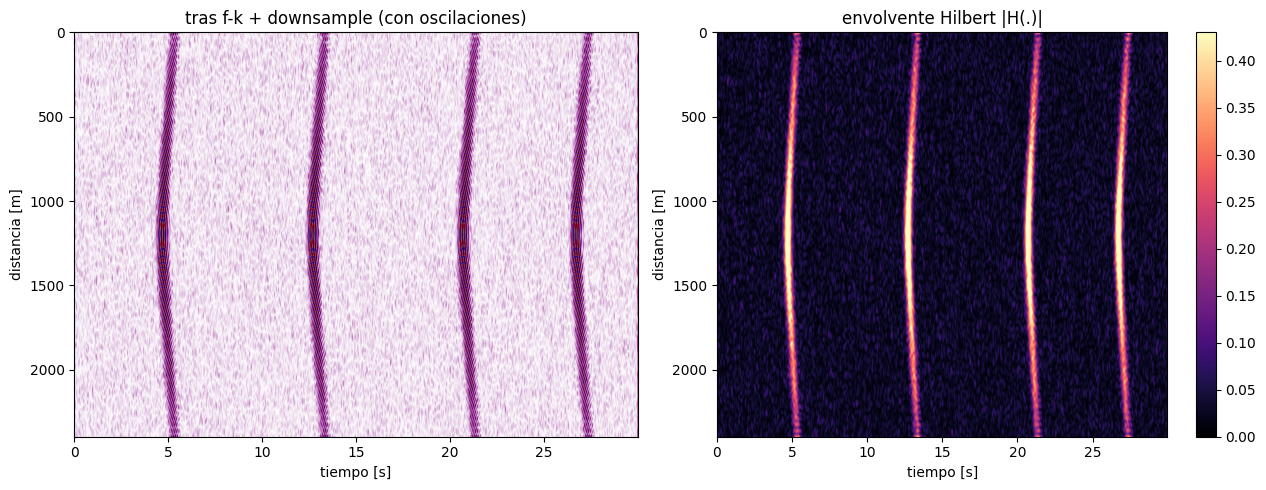

In [11]:
env2d = np.abs(hilbert(ds, axis=1)).astype(np.float32)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
show(ds,    'tras f-k + downsample (con oscilaciones)', axes[0], t_axis=t_ds)
extent_ds = [t_ds[0], t_ds[-1], x[-1], x[0]]
im = axes[1].imshow(env2d, aspect='auto', cmap='magma', extent=extent_ds,
                    vmin=0, vmax=np.percentile(env2d, 99))
axes[1].set_xlabel('tiempo [s]'); axes[1].set_ylabel('distancia [m]')
axes[1].set_title('envolvente Hilbert |H(.)|')
plt.colorbar(im, ax=axes[1])
plt.tight_layout(); plt.show()


Comparalas: la imagen de la izquierda alterna positivo/negativo dentro de cada chevron (los ciclos del chirp), mientras que la de la derecha es **siempre positiva** y suave — los chevrons aparecen como bandas brillantes continuas sobre fondo oscuro. Eso es exactamente lo que queremos pasarle a YOLO como uno de los tres canales de la imagen RGB.

---

## Recapitulando

| Paso | Qué hace | Por qué |
|---|---|---|
| Bandpass | Quita energía fuera de 14–30 Hz | Tira ruido fácil con un filtro temporal barato |
| f–k filter | Tira energía con `c_app < c_water` | Aprovecha la física: nada acústico del agua viaja por el cable más lento que `c_water` |
| Downsample | Baja `fs` de 200 a 50 Hz | Reduce datos 4× sin perder información útil (Nyquist holgado) |
| Hilbert | Pasa de oscilación a envolvente | Hace que el chevron sea un blob suave de energía, fácil de detectar visualmente |

**Siguiente paso lógico:** repetir los tres últimos pasos en **tres sub-bandas distintas** (p.ej. 15, 20, 25 Hz) y apilar las tres envolventes como canales R, G y B. Eso es lo que hace `build_rgb_image.py` y lo que hablamos en el mensaje anterior. Si quieres, lo construimos en un siguiente notebook a partir de éste.
